### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Arooj Ilyas
*   Your **student number**: 1012872900



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [3]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [4]:
response = requests.get(countries_list_url, headers=headers)
# Split the text by lines to get a clean Python list of names
valid_countries = response.text.strip().split('\n')

data_filtered = raw_data[raw_data['entity'].isin(valid_countries)].copy()
data_filtered = data_filtered[(data_filtered['year'] >= 1901) & (data_filtered['year'] <= 2023)]
pop_column_name = data_filtered.columns[-1]
data_pivoted = data_filtered.pivot(index='entity', columns='year', values=pop_column_name)
data_clean = data_pivoted.dropna()

print("Number of countries remaining after cleaning:", len(data_clean))

Number of countries remaining after cleaning: 196


In [5]:
data_clean

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,2733334.0,2765603.0,2796321.0,2827377.0,2858773.0,2890514.0,2922603.0,2955044.0,2985778.0,3014767.0,...,30254080.0,30573968.0,30765719.0,30565331.0,29807591.0,28938096.0,28444080.0,28237830.0,28213015.0,28300861.0
Vietnam,12199511.0,12734169.0,13412346.0,14126641.0,14878976.0,15671378.0,16505981.0,17385031.0,18088666.0,18608564.0,...,91679582.0,92823254.0,94000115.0,95176978.0,96237319.0,97173778.0,98079196.0,98935101.0,99680656.0,100352189.0
Yemen,2984894.0,3006808.0,3033193.0,3059809.0,3086657.0,3113742.0,3141063.0,3168624.0,3196638.0,3225110.0,...,30226311.0,31159378.0,32109023.0,33090923.0,34085181.0,35111416.0,36134867.0,37140234.0,38222878.0,39390800.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [6]:
### Part 1 - Time-series plot function
import matplotlib.pyplot as plt

def plot_country_trends(data, countries_list, title_suffix="", line_color="tab:blue"):
    num_countries = len(countries_list)
    fig, axes = plt.subplots(nrows=num_countries, ncols=1, figsize=(10, 3 * num_countries), sharex=True)

    # If there's only 1 country, matplotlib doesn't return an array of axes, so make it a list
    if num_countries == 1:
        axes = [axes]

    for i, country in enumerate(countries_list):
        if country in data.index:
            axes[i].plot(data.columns, data.loc[country], color=line_color, linewidth=2)
            axes[i].set_title(f"{country} ({title_suffix})", fontsize=12)
            axes[i].set_ylabel("Value")
            axes[i].grid(True, linestyle='--', alpha=0.5)
        else:
            axes[i].text(0.5, 0.5, f"Country '{country}' not found in dataset", ha='center', va='center')

    plt.xlabel("Year", fontsize=12)
    plt.tight_layout()
    plt.show()


### Part 2 - Apply StandardScalar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(data_clean)
data_scaled = pd.DataFrame(scaled_array, index=data_clean.index, columns=data_clean.columns)

In [7]:
data_scaled

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,-0.100165,-0.100047,-0.099763,-0.099484,-0.099208,-0.098936,-0.098672,-0.098414,-0.096248,-0.092059,...,-0.034059,-0.029623,-0.026427,-0.022423,-0.017953,-0.013063,-0.007375,-0.003373,-0.001763,0.001713
Albania,-0.210133,-0.210609,-0.211095,-0.211588,-0.212088,-0.212596,-0.213114,-0.213642,-0.214023,-0.214260,...,-0.246648,-0.247677,-0.248635,-0.249513,-0.250503,-0.251641,-0.252834,-0.254159,-0.255592,-0.257056
Algeria,-0.099160,-0.098461,-0.097624,-0.096782,-0.095934,-0.095080,-0.094224,-0.093365,-0.092700,-0.092229,...,0.011552,0.013996,0.016545,0.019132,0.021633,0.024039,0.026348,0.028763,0.031174,0.033249
Andorra,-0.232726,-0.233281,-0.233835,-0.234396,-0.234965,-0.235540,-0.236126,-0.236721,-0.237152,-0.237421,...,-0.266777,-0.267602,-0.268379,-0.269074,-0.269870,-0.270801,-0.271785,-0.272866,-0.274068,-0.275342
Angola,-0.146728,-0.148310,-0.149959,-0.151601,-0.153239,-0.154871,-0.156500,-0.158127,-0.159538,-0.160733,...,-0.074116,-0.069620,-0.064978,-0.060195,-0.055368,-0.050451,-0.045471,-0.040285,-0.035004,-0.029793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,-0.156518,-0.156610,-0.156777,-0.156950,-0.157129,-0.157316,-0.157511,-0.157715,-0.157832,-0.157861,...,-0.052114,-0.052588,-0.053920,-0.057906,-0.065601,-0.073903,-0.079425,-0.082776,-0.084907,-0.086371
Vietnam,0.107849,0.120210,0.136253,0.153063,0.170677,0.189130,0.208459,0.228705,0.244040,0.254323,...,0.384787,0.386222,0.387904,0.389559,0.390787,0.391611,0.392784,0.394463,0.395622,0.396112
Yemen,-0.149492,-0.149912,-0.150238,-0.150573,-0.150915,-0.151265,-0.151625,-0.151996,-0.152221,-0.152301,...,-0.052311,-0.048461,-0.044534,-0.040415,-0.036213,-0.031787,-0.027272,-0.022681,-0.017604,-0.012108


In [8]:
!pip install python-Levenshtein -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.6 MB/s eta 0:00:00


In [9]:
### Part 3 - Levishtein.distance() to calculate distance
import Levenshtein

# Calculate the distance from "Arooj" to every country in the dataset
my_name = "Arooj"
distance_results = []

for country_name in data_clean.index:
    distance = Levenshtein.distance(my_name, country_name)
    distance_results.append((country_name, distance))

distance_results.sort(key=lambda x: x[1])

closest_one = distance_results[0][0]
closest_two = distance_results[1][0]
print(f"Closest country 1: {closest_one} (Distance: {distance_results[0][1]})")
print(f"Closest country 2: {closest_two} (Distance: {distance_results[1][1]})")

Closest country 1: Angola (Distance: 4)
Closest country 2: Gabon (Distance: 4)


In [10]:
### Part 4 - Run function from Part 1
required_countries = ['Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']
final_country_list = [closest_one, closest_two]

# Filter through required_countries list and add any not already included in final_country_list
for country in required_countries:
    if country not in final_country_list:
        final_country_list.append(country)

print("\nFinal list of countries:", final_country_list)


Final list of countries: ['Angola', 'Gabon', 'Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']


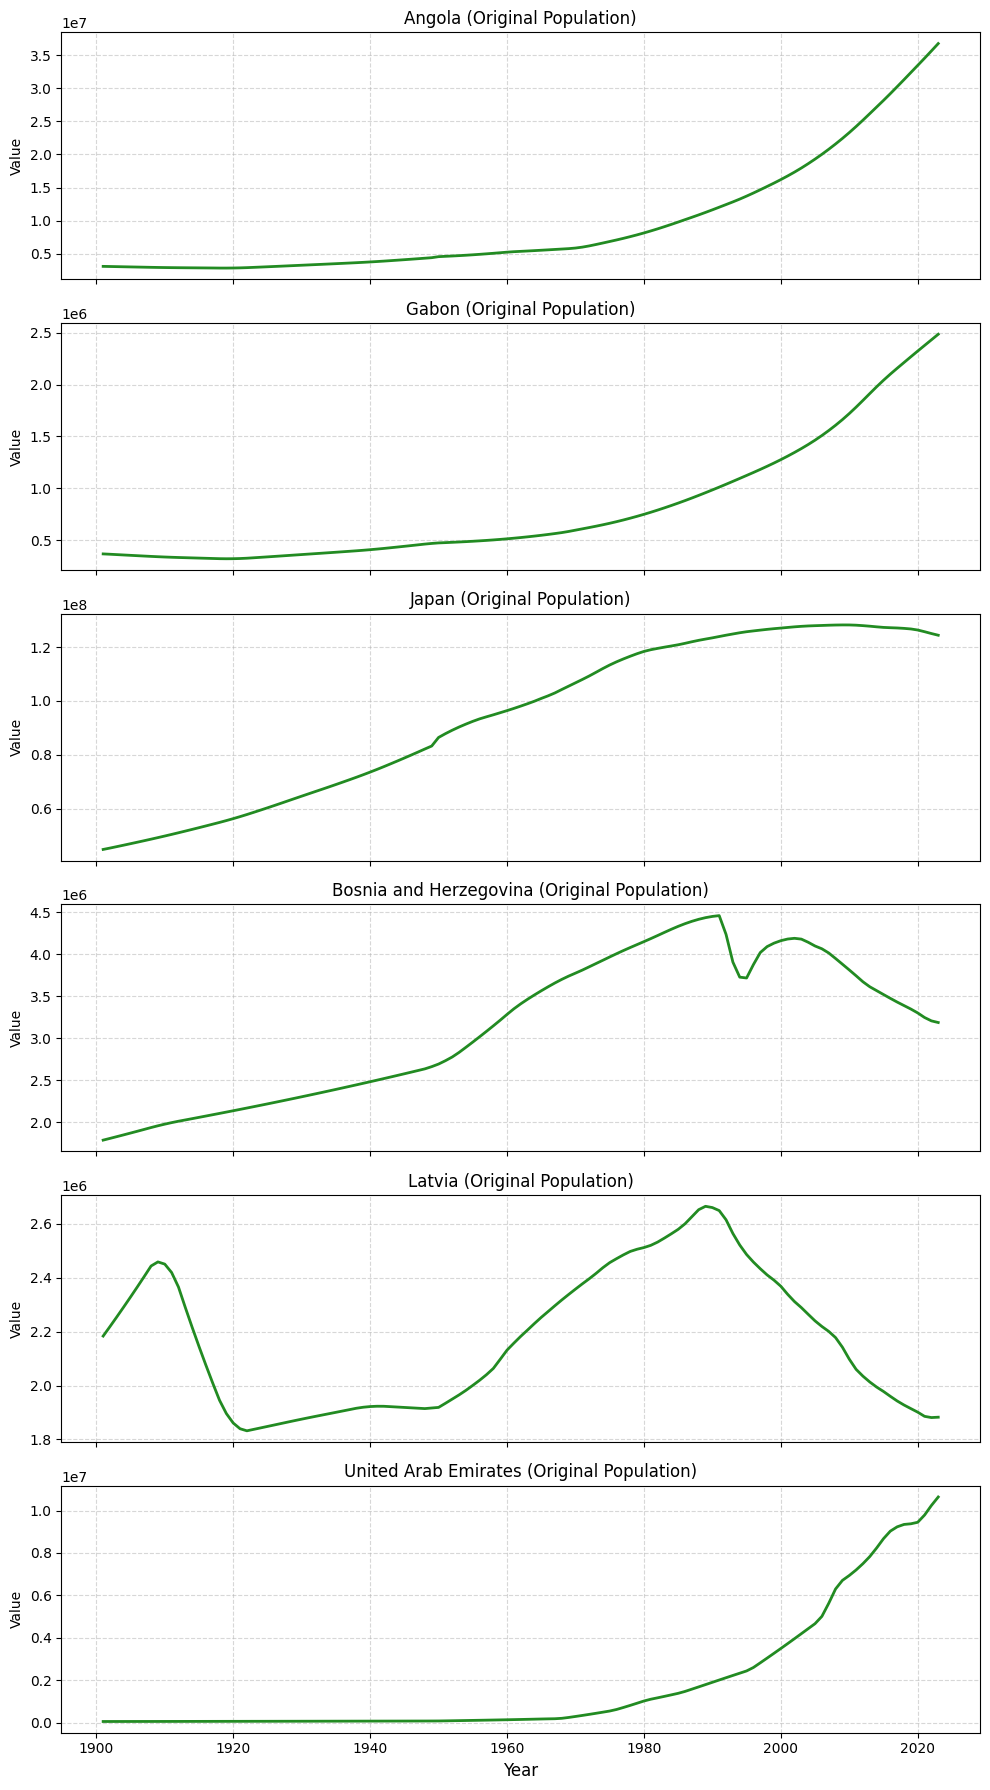

In [11]:
# Plot the original population
plot_country_trends(
    data=data_clean,
    countries_list=final_country_list,
    title_suffix="Original Population",
    line_color="forestgreen"
)

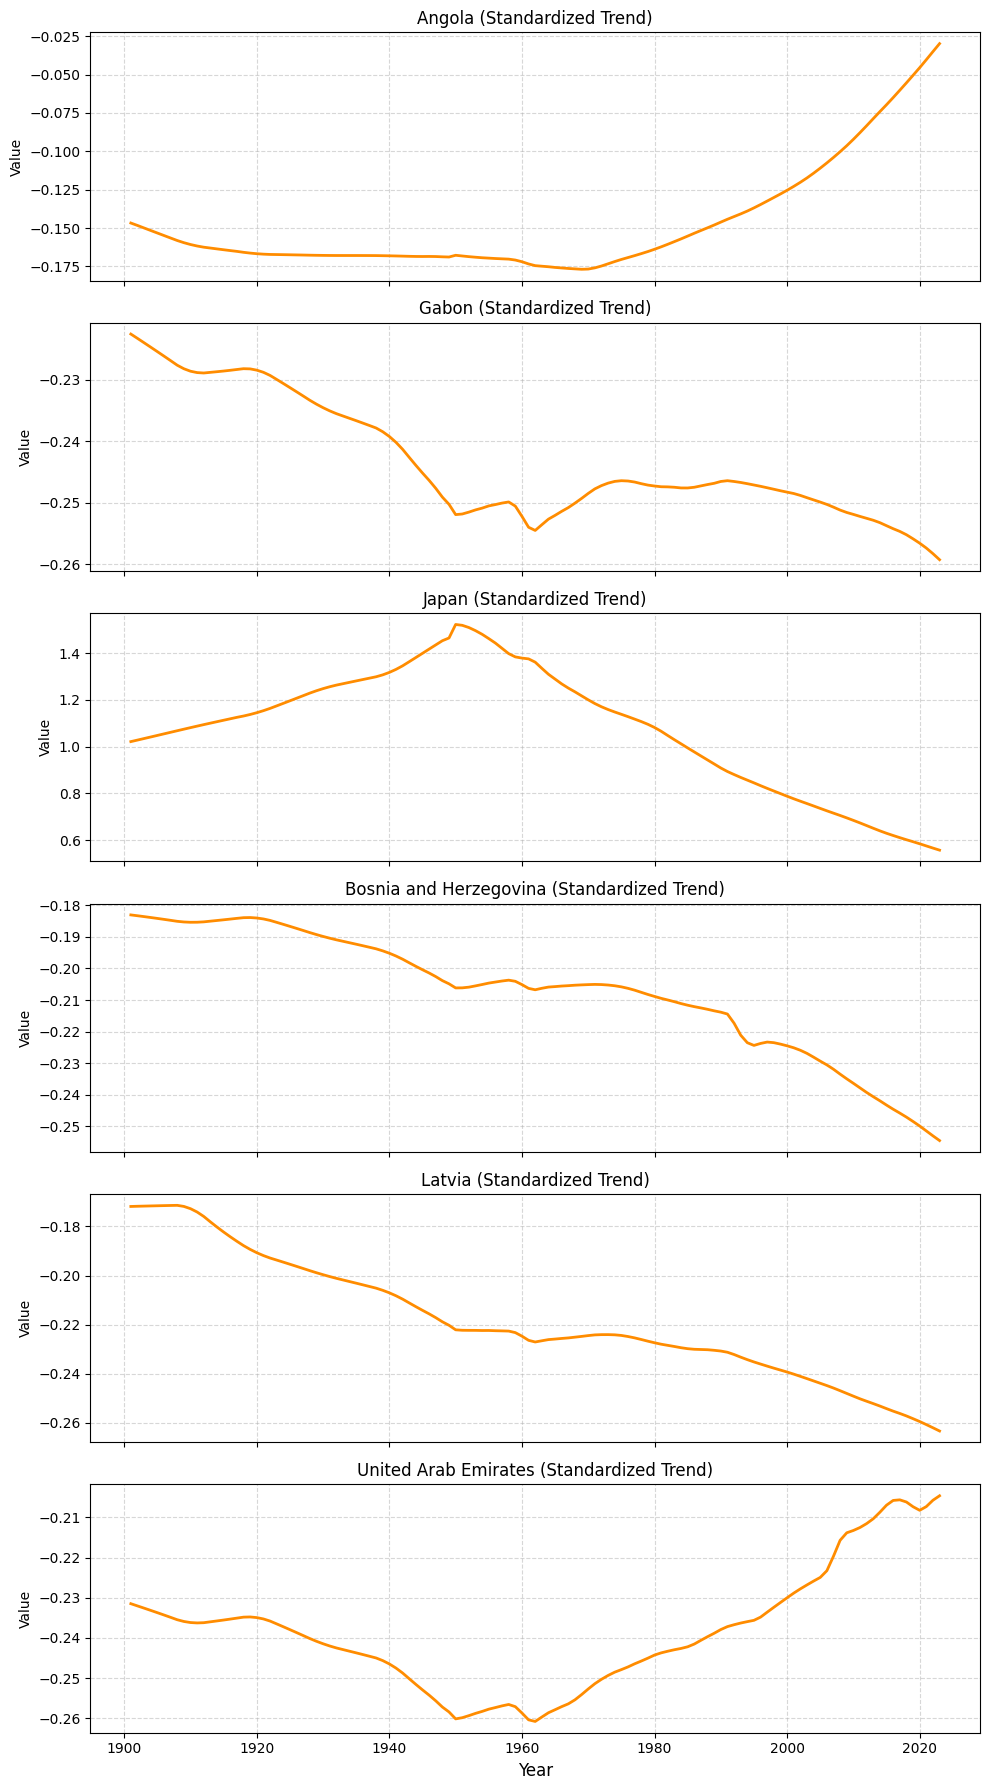

In [12]:
# Plot the standardized trend
plot_country_trends(
    data=data_scaled,
    countries_list=final_country_list,
    title_suffix="Standardized Trend",
    line_color="darkorange"
)

### Part 5 - Discussion

**What does it mean if the standardized curve goes up or down?**
*  When the curve **goes up**, it means its population is growing faster than the avg global growth rate for that year; expanding its share of the global population pool.
*  When the curve **goes down**, it means the country's population is growing slower than the global average; staying stagnant, or actively shrinking relative to the other countries in the dataset

**What does the sign of the values indicate?**
* **Positive** ($> 0$): Country's population in that given year is above the avg population size of countries in the dataset for that year.
*   **Negative** ($< 0$): Country's population in that given year is below the avg population size of countries in the dataset for that year.
*   **Zero** ($0$): Represents a population size exactly equal to the global country avg for that year.

